# Sentinel-1 Flood Duration by Land-Cover Class
## 2016-2017 Southern Thailand Flood, Mueang Nakhon Si Thammarat District

This notebook estimates the flood duration during the 2016-2017 Southern Thailand flood using Sentinel-1 SAR imagery and Google Earth Engine (GEE). The analysis focuses on Mueang Nakhon Si Thammarat District and compares the mean flood duration across vegetation, urban, and agricultural/bare land-cover classes.

The full project overview is provided in the README file.

## Project workflow

1. Filter Sentinel-1 SAR imagery for the flood event and study area.
2. Train a Random Forest classifier using Sentinel-1 composite and reference flood data.
3. Classify flood/non-flood pixels across the remaining Sentinel-1 image time series.
4. Estimate flood duration from repeated flood detections and Sentinel-1 sampling interval.
5. Overlay flood duration with land-cover classes.
6. Interpret results using elevation and rainfall data.

## 1) Imports and Functions

In [1]:
!pip install xee==0.0.24

In [2]:
# Importing relevant libraries
import xee
import ee
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
%matplotlib inline

In [3]:
# Creating a directory to store downloaded files
directory = Path("data")
directory.mkdir(parents = True, exist_ok = True)
print("Data directory:", directory.resolve())

Data directory: /content/data


In [4]:
# Function 1: Authenticate GEE
# Adapted from UCL GEOG0111 teaching materials
def auth_gee(project_id: str, use_highvolume: bool = True) -> None:
    """
    Authenticate and initialize Google Earth Engine using a specified project ID

    Input:
    - project_id: Google Earth Engine project ID
    - use_highvolume: If True, use the Earth Engine high-volume API endpoint
    """
    ee.Authenticate()
    if use_highvolume:
        ee.Initialize(project=project_id,
                     opt_url='https://earthengine-highvolume.googleapis.com')
    else:
        ee.Initialize(project=project_id)

In [5]:
# Function 2: Importing the S1 ImageCollection and filtering based on event dates and geometry
def preprocess_s1(S1_IC: ee.ImageCollection,
                  event_IC: ee.FeatureCollection,
                  country: str,
                  province: str,
                  district: str,
                  start_date: str,
                  end_date: str) -> tuple[ee.ImageCollection, ee.Geometry]:
  """
  Preprocess Sentinel-1 image collection by filtering to keep only images within the flood event date ranges and AOI.

  Input:
  - S1_IC: Sentinel-1 image collection (COPERNICUS/S1_GRD)
  - event_IC: DIstrict boundaries image collection (FAO/GAUL_SIMPLIFIED_500m/2015/level2)
  - country: Name of the country.
  - province: Name of the province.
  - district: Name of the district.
  - start_date: Start date of flood event.
  - end_date: End date of flood event.

  Output:
  - S1_IC_filtered: Filtered Sentinel-1 image collection.
  """
  # Extracting flood geometry
  event_filtered = (event_IC
                    .filter(ee.Filter.eq('ADM0_NAME', country))
                    .filter(ee.Filter.eq('ADM1_NAME', province))
                    .filter(ee.Filter.eq('ADM2_NAME', district)))
  assert event_filtered.size().getInfo() > 0, f"Country {country}/ Province {province}/ District {district} not found."
  event_img = event_filtered.first()
  AOI = event_img.geometry()


  # Filtering the S1 ImageCollection by dates and AOI, as well as filtering to keep only data with VV and VH bands for consistency
  S1_IC_filtered = (
      S1_IC
      .filterDate(start_date, end_date)
      .filterBounds(AOI)
      .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
      .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH")))


  # Testing whether the filtered ImageCollection contains any images and the correct bands
  assert S1_IC_filtered.size().getInfo() > 0, "No images found in the filtered collection."
  band_names = S1_IC_filtered.first().bandNames().getInfo()
  assert ("VV" in band_names) and ("VH" in band_names), f"VV and/or VH not found. Available bands: {band_names}"

  return S1_IC_filtered, AOI

In [6]:
# Function 3: Filter for only images with large AOI coverage.
  # Due to the nature of S1 orbit, only 1 out of 2 consecutive images actually have a large coverage of the AOI.
  # So, a filter was applied to keep only these images (now 12 days apart)
def AOI_coverage_filter(S1_IC_filtered: ee.ImageCollection,
                        AOI: ee.Geometry,
                        scale: int = 250,
                        min_coverage: float = 0.90) -> ee.ImageCollection:
  """Filter the Sentinel-1 image collection to keep only images with a AOI coverage >= min_coverage.

  Inputs:
  - S1_IC_filtered: The filtered Sentinel-1 ImageCollection
  - AOI: The event's area of interest
  - scale: Sampling scale
  - min_coverage: Minimum AOI fraction coverage

  Outputs:
  - S1_IC_coverage: The filtered ImageCollection with only images with a large AOI coverage
  """

  # Defining a function to calculate the AOI coverage fraction for a single image
  def add_coverage(image):
        image = ee.Image(image).clip(AOI)

        # Creating a mask from VV band: 1 where data exists, 0 where missing
        coverage_mask = image.select("VV").mask().rename("coverage").unmask(0)

        # Mean of 0/1 over AOI = fraction observed
        cov = ee.Number(
            coverage_mask.reduceRegion(
            reducer = ee.Reducer.mean(),
            geometry = AOI,
            scale = scale,
            maxPixels = 1e13,
            tileScale = 4).get("coverage"))

        return image.set("coverage_fraction", cov)

  # Mapping the function over the ImageCollection
  S1_IC_coverage = S1_IC_filtered.map(add_coverage)
  return S1_IC_coverage.filter(ee.Filter.gte("coverage_fraction", min_coverage))

In [7]:
# Function 4: Training a randomforest classifier on Sentinel-1 and flood reference data
def train_rf(
    S1_IC_coverage: ee.ImageCollection,
    AOI: ee.Geometry,
    ref_IC: ee.ImageCollection,
    flood_id: int,
    points_per_class: int = 500,
    train_fraction: float = 0.7,
    n_trees: int = 100,
    scale: int = 250,
    seed: int = 42,
) -> tuple[ee.Classifier, dict]:
  """ Train a randomforest classifier on Sentinel-1 data and flood reference data.

  Inputs:
  - S1_IC_coverage: The filtered Sentinel-1 ImageCollection
  - AOI: The event's area of interest
  - ref_IC: Reference image collection (GLOBAL_FLOOD_DB/MODIS_EVENTS/V1)
  - flood_id: Flood event ID in ref_IC
  - points_per_class: Number of points per class (0 = non-flood, 1 = flood)
  - train_fraction: Fraction of data to use for training. The remainder (1 - train_fraction) is used for testing/validation.
  - n_trees: Number of trees for randomforest
  - scale: Sampling scale (metres)
  - seed: Random seed for sampling and train/test split

  Outputs:
  - classfier: The trained randomforest classifier
  - metrics: A dictionary containing accuracy metrics (confusion matrix, overall accuracy, producer's accuracy, consumer's acccuracy)
  """

  # Making a Sentinel-1 composite and features
  S1_IC_composite = S1_IC_coverage.select(["VV", "VH"]).median().clip(AOI)
    # Adding one derived feature (VV-VH) to aid in classification
  vv_minus_vh = S1_IC_composite.select("VV").subtract(S1_IC_composite.select("VH")).rename("VV_minus_VH")
  features = S1_IC_composite.addBands(vv_minus_vh)


  # Extracting the flood class reference data and separating it from permanent water bodies
  ref_image = ref_IC.filter(ee.Filter.eq('id', flood_id)).first()
  flood_image = ref_image.select('flooded').rename('class').toInt()

  permanent_water = ref_image.select("jrc_perm_water")
  label = flood_image.updateMask(permanent_water.eq(0)).clip(AOI) # Masking out permanent water pixels
  combined_image = features.addBands(label)


  # Creating ground control points and splitting it into training and testing points
  gcps = combined_image.stratifiedSample(numPoints = points_per_class,
                                         classBand = 'class',
                                         region = AOI,
                                         scale = scale,
                                         seed = seed,
                                         geometries = False)
  gcps_random = gcps.randomColumn('random', seed)

  training_points = gcps_random.filter(ee.Filter.lt('random', train_fraction))
  testing_points = gcps_random.filter(ee.Filter.gte('random', train_fraction))


  # Training the randomforest classifier using training points
  band_names = features.bandNames()
  classifier = (ee.Classifier
                .smileRandomForest(numberOfTrees = n_trees, seed = seed)
                .train(features = training_points, classProperty = "class", inputProperties = band_names))


  # Validating using testing points and getting accuracy metrics from the confusion matrix
  prediction = testing_points.classify(classifier)
  confusion_matrix = prediction.errorMatrix("class", "classification")

  accuracy_metrics = {
      "confusion_matrix": confusion_matrix.getInfo(),
      "overall_accuracy": confusion_matrix.accuracy().getInfo(),
      "producers_accuracy": confusion_matrix.producersAccuracy().getInfo(),
      "users_accuracy": confusion_matrix.consumersAccuracy().getInfo()}


  return classifier, accuracy_metrics

In [8]:
# Function 5: Classify the ImageCollection
def classify_IC(S1_IC_coverage: ee.ImageCollection, AOI: ee.Geometry, classifier: ee.Classifier) -> ee.ImageCollection:
  """ Classify the pixels in each image of the filtered ImageCollection from the AOI_coverage_filter function into flood and non-flood pixels, using the trained classifier from the train_rf function.

  Inputs:
  - S1_IC_coverage: The filtered Sentinel-1 ImageCollection. This is the ImageCollection to be classified.
  - AOI: The event's area of interest
  - classifier: The trained randomforest classifier

  Outputs:
  - classified_IC: The classified ImageCollection containing the binary flood class (0 = non-flood, 1 = flood) for each pixel of each image, stored in the band "flood"
  """

  # Defining a function to apply the classifier over one image
  def classify_image(image):
    # Extracting the features needed for classification (same as the ones used in function 5: VV, VH, VV-VH) from the image
    image_filtered = ee.Image(image).clip(AOI).select(["VV", "VH"])
    vv_minus_vh = image_filtered.select("VV").subtract(image_filtered.select("VH")).rename("VV_minus_VH")
    features = image_filtered.addBands(vv_minus_vh)

    # Classify the image, renaming the classified band to 'flood'
    flood_image = features.classify(classifier).rename("flood").toInt()

    # Preserve time for later flood-duration calculation
    return flood_image.set("system:time_start", image.get("system:time_start"))


  # Mapping the function over the ImageCollection
  classified_IC = S1_IC_coverage.map(classify_image).sort("system:time_start")
  return classified_IC

In [9]:
# Function 6: Flood duration per pixel from how many images it remained flooded
def flood_duration(classified_IC: ee.ImageCollection, AOI: ee.Geometry, interval: int = 12, band: str = "flood") -> ee.Image:
  """ Find the flood duration for each pixel in days over the AOI, based on how many images it remained flooded for and the time interval between each image.
  The duration data is stored in the band "flood_duration".

  Inputs:
  - classified_IC: The classified ImageCollection
  - AOI: The event's area of interest
  - interval: The collection interval between each image in days
  - band: The band to use for the flood duration calculation

  Output:
  - flood_duration: The image containing the flood duration in days for each pixel in the AOI
  """

  duration = classified_IC.select(band).sum().multiply(interval).rename("flood_duration").toUint16().clip(AOI)

  return duration

In [10]:
# Function 7: robust validate the duration image
class DatasetValidationError(Exception):
    """Raised when dataset validation fails."""
    pass

def robust_validate_duration(duration_image: ee.Image, AOI: ee.Geometry, n_images: int, interval: int, scale: int = 250, flood_band: str = "flood_duration", raise_on_fail: bool = True) -> dict:
  """ Run 4 checks on the flood duration image to ensure data quality.
  Checks:
  1) The flood duration band exist in the image.
  2) The value range of the pixels is within the expected range.
  3) Pixels containing non-zero values exist. This is to test whether flood was detected.
  4) Pixel values are multiples of intervals. This is to check data consistency with the Sentinel-1 revisit interval.

  Inputs:
  - duration_image: The image containing the flood duration in days for each pixel in the AOI
  - AOI: The event's area of interest
  - n_images: The number of images used to calculate the flood duration
  - interval: The collection interval between each image in days
  - scale: Sampling scale (metres)
  - flood_band: The name of the band containing the flood duration data
  - raise_on_fail: If True, raise DatasetValidationError when a check fails. If False, just return a report dict.

  Output:
  - check_results: A dictionary containing the results of each check
  """

  report: dict[str, tuple[bool, str]] = {}

  # Check 1: The flood duration band exist in the image.
  bands = duration_image.bandNames().getInfo()
  if flood_band in bands:
        report["has_flood_band"] = (True, f"Band '{flood_band}' found.")
  else:
        msg = f"Band '{flood_band}' not found. Bands present: {bands}"
        report["has_flood_band"] = (False, msg)
        if raise_on_fail:
            raise DatasetValidationError(msg)
        return report


  # Check 2: The value range of the pixels is within the expected range
    # Determining the appropriate min and max thresholds
  min_lim = 0
  max_lim = n_images * interval

    # Calculating the min and max pixel value in the duration image
  stats = duration_image.select(flood_band).reduceRegion(reducer = ee.Reducer.minMax(), geometry = AOI, scale = scale, maxPixels = 1e13).getInfo()
  vmin = stats.get(f"{flood_band}_min", None)
  vmax = stats.get(f"{flood_band}_max", None)

    # Checking whether the calculated min and max value falls within expected range
  if vmin >= min_lim and vmax <= max_lim:
    report[f"value_range_ok"] = (True, f"[{vmin:.3f}, {vmax:.3f}], within [{min_lim}, {max_lim}].")
  else:
    msg = (f"range [{vmin:.3f}, {vmax:.3f}] outside expected [{min_lim}, {max_lim}].")
    report[f"value_range_ok"] = (False, msg)
    if raise_on_fail:
      raise DatasetValidationError(msg)
    return report


# Check 3: Pixels containing non-zero values exist
  if vmax is not None and vmax > 0:
      report["flood_detected"] = (True, f"Non-zero pixels found. Maximum detected flood duration: {vmax} days.")
  else:
      msg = "Validation failed: No flooded pixels detected in the duration image (all values are 0)."
      report["flood_detected"] = (False, msg)
      if raise_on_fail:
          raise DatasetValidationError(msg)
      return report


# Check 4: Pixel values are multiples of intervals
  # As duration (days) = n_images (int) * intervals (days), the remainder when dividing duration by intervals should be 0 for all pixels
  remainder_img = duration_image.select(flood_band).mod(interval)
  # Computing the unique values in the remainder image. Ideally should have only one entry with value = 0.
  remainder_hist = remainder_img.reduceRegion(reducer = ee.Reducer.frequencyHistogram(), geometry = AOI, scale = scale, maxPixels=1e13).getInfo()
  hist = remainder_hist.get(flood_band, {})
  # Converting keys to integers
  remainders = set(int(float(k)) for k in hist.keys()) if hist else set()

  if remainders == {0}:
      report["interval_multiple_ok"] = (True, f"All pixel values are multiples of {interval} days (remainder set = {remainders}).")
  else:
      msg = f"Found non-zero remainders {sorted(remainders)} when taking value mod {interval}. Values not consistent with the revisit interval."
      report["interval_multiple_ok"] = (False, msg)
      if raise_on_fail:
          raise DatasetValidationError(msg)
      return report

  return report

In [11]:
# Function 8: Overlaying the flood duration on land cover classes and find the mean flood duration for each class
  # Note that this function only overlays the flood image with the land cover classes and calculates the mean duration per class.
  # The filtered land cover image must be defined before and outside this function. This is to keep the function as general as possible in case other datasets are to be used.
def flood_duration_per_class(duration_image: ee.Image, AOI: ee.Geometry, land_cover_image: ee.Image, flood_duration_band: str, land_cover_band: str, scale: int = 250) -> ee.Dictionary:
  """ Find the mean flood duration for each land cover class.

  Inputs:
  - duration: The image containing the flood duration in days for each pixel in the AOI
  - AOI: The event's area of interest
  - land_cover: The image containing the land cover classes
  - flood_duration_band: The name of the band containing the flood duration data
  - land_cover_band: The name of the band containing the land cover classes data
  - scale: Sampling scale (metres)

  Output:
  - flood_duration_per_class: A dictionary containing the mean flood duration for each land cover class
  """
  # Adding the land cover data to the bandlist of the image containing the flood duration data (band 0 = flood_duration_band, band 1 = land_cover_band)
  duration_image_selected = duration_image.select(flood_duration_band)
  land_cover_image_selected  = land_cover_image.select(land_cover_band)
  flood_land_cover = duration_image_selected.addBands(land_cover_image_selected).clip(AOI)


  # Using a reducer to calculate the mean flood duration per land class in days
  flood_per_class = flood_land_cover.reduceRegion(reducer = ee.Reducer.mean().group(groupField = 1, groupName = "land_class"), geometry = AOI, scale = scale, maxPixels = 1e13)


  return flood_per_class

In [12]:
# Function 9: Writing ee.Dict into a pandas dataframe
def dict_to_df(dictionary: ee.Dictionary, dict_key: str = "groups", class_column: str = "land_class", class_map: dict = None) -> pd.DataFrame:
  """ Convert an ee.Dictionary into a pandas dataframe.

  Inputs:
  - dictionary: The ee.Dictionary to convert
  - dict_key: The key the ee.Reducer.mean wraps their results in. This is usually "groups".
  - class_column: The column containing the class codes
  - class_map: A dictionary mapping the class codes to the class names.

  Output:
  - df: The pandas dataframe containing the data
  """

  # Converting the ee.Dict into pd dataframe
  dict_info = dictionary.getInfo()
  data = dict_info.get(dict_key, [])
  df = pd.DataFrame(data)

  # Adding intuitive class names to the dataframe
  if class_map is not None and class_column in df.columns:
    df["class_name"] = df[class_column].map(class_map)

  return df

In [13]:
# Function 10: Extracting data from an Image into xarray Dataset. This is so it can be plotted.
def image_to_xarray(image: ee.Image, AOI: ee.Geometry, bands: str | list[str] | None = None, scale: int = 250, crs: str = "EPSG:4326") -> xr.Dataset:
  """ Convert a single ee.Image into an xarray dataset

  Input:
  - image: The ee.Image to convert
  - AOI: The event's area of interest
  - bands: The band(s) containing the data to export
  - scale: Sampling scale (metres)
  - crs: Coordinate reference system

  Output:
  - xr_dataset: The xarray dataset containing the requested band(s) over the AOI
  """
  image = image.clip(AOI)
  if bands is not None:
    image = image.select(bands)

  # Converting scale from metres to degrees for EPSG:4326
  scale_deg = scale / 111100
  xr_dataset = xr.open_dataset(image, geometry = AOI, engine = 'ee', scale = scale_deg, crs = crs)

  return xr_dataset

## 2) Data Analysis

#### 2.1) Filtering the S1 ImageCollection

In [14]:
# Authenticating GEE
# Replace "YOUR-PROJECT-ID" with your own GEE project ID
auth_gee(project_id="YOUR-PROJECT-ID")

In [15]:
# Filtering the Sentinel-1 ImageCollection
S1_IC = ee.ImageCollection("COPERNICUS/S1_GRD")
event_IC = ee.FeatureCollection("FAO/GAUL_SIMPLIFIED_500m/2015/level2")


  # Filtering by dates and AOI
S1_IC_filtered, AOI = preprocess_s1(
    S1_IC = S1_IC,
    event_IC = event_IC,
    country = 'Thailand',
    province = 'Nakhon Si Thammarat',
    district = 'Muang Nakhon Si Thammarat',
    start_date = "2016-12-15",
    end_date = "2017-02-15")


  # Filtering by AOI fraction coverage
S1_IC_coverage = AOI_coverage_filter(S1_IC_filtered = S1_IC_filtered, AOI = AOI, scale = 250, min_coverage = 0.90)
    # Comparing the number of images remaining in the ImageCollection before and after
print("Filtering by AOI coverage fraction")
print("Before:", S1_IC_filtered.size().getInfo())
print("After :", S1_IC_coverage.size().getInfo(), "\n")


# Printing the date of each remaining images
img_list = S1_IC_coverage.toList(S1_IC_coverage.size())
number_img = S1_IC_coverage.size().getInfo()
print("Dates of images:")
for i in range(number_img):
    img = ee.Image(img_list.get(i))
    date = ee.Date(img.get("system:time_start")).format("YYYY-MM-dd").getInfo()
    print(f"{i+1}: {date}")

Filtering by AOI coverage fraction
Before: 11
After : 5 

Dates of images:
1: 2016-12-21
2: 2017-01-02
3: 2017-01-14
4: 2017-01-26
5: 2017-02-07


#### 2.2) Randomforest classifier

In [16]:
# Training the randomforest classifier on Sentinel-1 and flood reference data
ref_IC = ee.ImageCollection("GLOBAL_FLOOD_DB/MODIS_EVENTS/V1")

classifier, accuracy_metrics = train_rf(
    S1_IC_coverage = S1_IC_coverage,
    AOI = AOI,
    ref_IC = ref_IC,
    flood_id = 4432,
    points_per_class = 100,
    train_fraction = 0.7,
    n_trees = 50,
    scale = 250,
    seed = 42)

# Printing the accuracy metrics (class: 0 = non-flood, 1 = flood)
for k, v in accuracy_metrics.items():
    print(f"{k}: {v}")

confusion_matrix: [[31, 4], [5, 31]]
overall_accuracy: 0.8732394366197183
producers_accuracy: [[0.8857142857142857], [0.8611111111111112]]
users_accuracy: [[0.8611111111111112, 0.8857142857142857]]


- 87.3% OA: good agreement between predicted and reference flood labels.

- 88.6% PA for non-flood and 86.1% for flood: most reference flood and non-flood areas were successfully detected by the classifier.

- 86.1% UA for non-flood and 88.6% for flood: predicted flood pixels were generally reliable.

In [17]:
# Using the trained randomforest classifier to classify the images
classified_IC = classify_IC(S1_IC_coverage, AOI, classifier)
print("Classified images:", classified_IC.size().getInfo())
print("Bands Available:", ee.Image(classified_IC.first()).bandNames().getInfo())

Classified images: 5
Bands Available: ['flood']


FrozenMappingWarningOnValuesAccess({'time': 1, 'lon': 134, 'lat': 158})
FrozenMappingWarningOnValuesAccess({'time': 1, 'lon': 134, 'lat': 158})
FrozenMappingWarningOnValuesAccess({'time': 1, 'lon': 134, 'lat': 158})
FrozenMappingWarningOnValuesAccess({'time': 1, 'lon': 134, 'lat': 158})
FrozenMappingWarningOnValuesAccess({'time': 1, 'lon': 134, 'lat': 158})


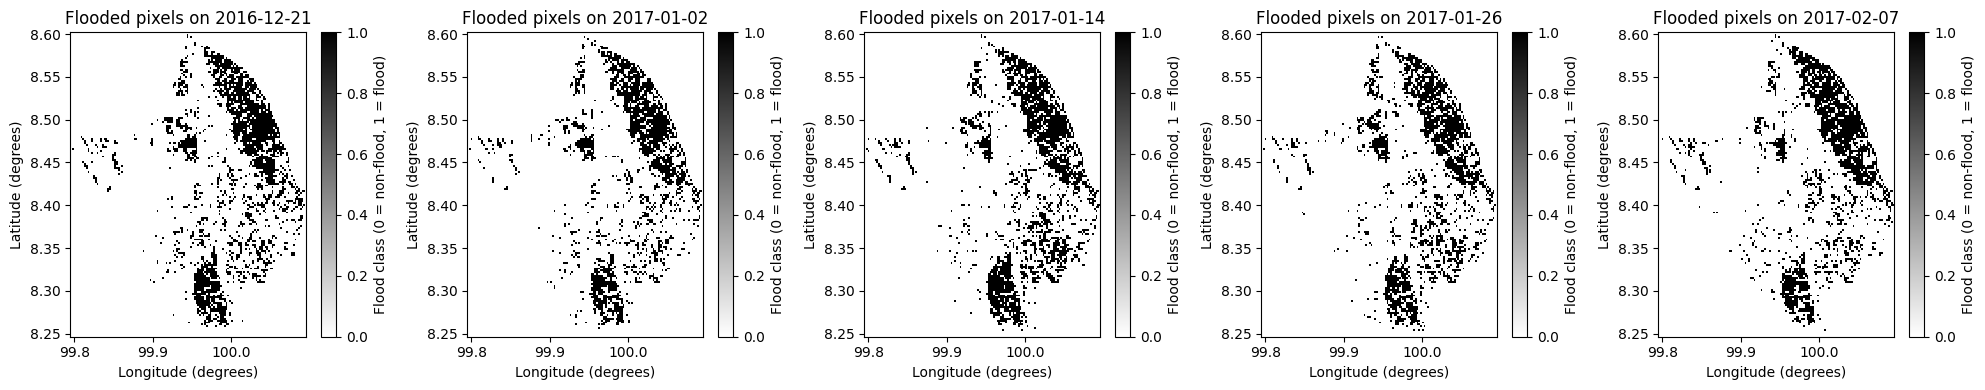

In [18]:
# Plotting the classified flood to check whether they were classified properly
fig_flood, ax_flood = plt.subplots(1, 5, figsize = (20,4))

count = classified_IC.size().getInfo()
img_list = classified_IC.toList(count)
for i in range(count):
    classified_img = ee.Image(img_list.get(i))

    # Getting the date string for the title
    date_str = ee.Date(classified_img.get("system:time_start")).format("YYYY-MM-dd").getInfo()

    # Converting to xarray
    classified_xarray = image_to_xarray(classified_img, AOI = AOI, bands = "flood", scale = 250, crs = "EPSG:4326")
    print(classified_xarray.dims)

    # Plotting the xarray
    classified_xarray.flood.isel(time = 0).plot.imshow(x = 'lon', y = 'lat', robust = True, cmap = 'gray_r', ax = ax_flood[i], cbar_kwargs = {"label": "Flood class (0 = non-flood, 1 = flood)"})
    ax_flood[i].set_title(f"Flooded pixels on {date_str}")
    ax_flood[i].set_xlabel("Longitude (degrees)")
    ax_flood[i].set_ylabel("Latitude (degrees)")

plt.tight_layout()
plt.show()

#### 2.3) Calculating flood duration per pixel

In [19]:
# Creating the flood duration image
duration = flood_duration(classified_IC, AOI, interval = 12, band = "flood")

# Robust validate the flood duration image
validation_report = robust_validate_duration(duration, AOI, n_images = 5, interval = 12, scale = 250, flood_band = "flood_duration", raise_on_fail = False)
print("Validation report:\n")
for check, (passed, msg) in validation_report.items():
    status = "✅" if passed else "❌"
    print(f"{status} {check}: {msg}")

Validation report:

✅ has_flood_band: Band 'flood_duration' found.
✅ value_range_ok: [0.000, 60.000], within [0, 60].
✅ flood_detected: Non-zero pixels found. Maximum detected flood duration: 60 days.
✅ interval_multiple_ok: All pixel values are multiples of 12 days (remainder set = {0}).


#### 2.4) Overlaying with land cover data

In [20]:
# Defining the land cover data
start_date = "2016-12-15"
end_date = "2017-02-15"
land_cover_data = ee.ImageCollection("COPERNICUS/Landcover/100m/Proba-V-C3/Global").filterDate(start_date, end_date).first().select("discrete_classification")


# Re-classifying the land cover data into 3 groups (1- Vegetation, 2- Urban, 3- Agricultural/Bare)
  # Excluding water classes (code: 80, 200) and nodata class (code: 0)
mask = land_cover_data.neq(0).And(land_cover_data.neq(80)).And(land_cover_data.neq(200))
land_cover_masked = land_cover_data.updateMask(mask)

  # Re-classifying the land cover data into 3 groups
vegetation_codes  = [20, 30, 90, 100, 111, 112, 113, 114, 115, 116, 121, 122, 123, 124, 125, 126]
urban_codes = [50]
agricultural_and_bare_codes  = [40, 60, 70]

original_codes = vegetation_codes + urban_codes + agricultural_and_bare_codes
re_classified_codes  = [1]*len(vegetation_codes) + [2]*len(urban_codes) + [3]*len(agricultural_and_bare_codes)
descriptive_labels = ["Vegetation", "Urban", "Agricultural/Bare"]

land_cover_reclassified = land_cover_masked.remap(original_codes, re_classified_codes).rename("land_cover")

In [21]:
# Calculating the mean flood duration per land class in days
mean_per_class = flood_duration_per_class(duration, AOI, land_cover_reclassified, "flood_duration", "land_cover", scale = 250)

# Converting the ee.Dict into a pandas dataframe
class_map = {1: "Vegetation", 2: "Urban", 3: "Agricultural/Bare"}
df = dict_to_df(mean_per_class, dict_key = "groups", class_column = "land_class", class_map = class_map)

# Saving the summary table (Table 1)
csv_path = directory / "Table_1_summary.csv"
df.to_csv(csv_path, index = False)
print("Table 1 saved to:", csv_path.resolve())

Table 1 saved to: /content/data/Table_1_summary.csv


## 3) Results and Interpretations

#### 3.1) The Geography and flooding of Mueang Nakhon Si Thammarat District

/usr/local/lib/python3.12/dist-packages/xee/ext.py:696: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


Figure 1 saved to: /content/data/Fig_1_duration.png


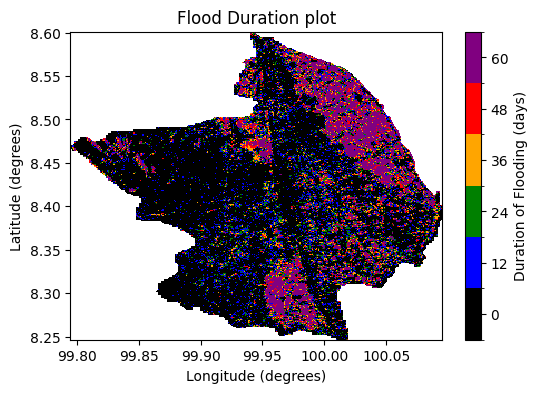

In [22]:
# Plotting the flood duration image
  # Converting the flood duration image into xarray dataset
duration_xarray = image_to_xarray(duration, AOI, bands = "flood_duration", scale = 100, crs = "EPSG:4326")

fig_duration = plt.figure(figsize = (6, 4))
tick_locations_flood = [-12, 0, 12, 24, 36, 48, 60] # Adding -12 to centre the label 0
duration_levels = [-6, 6, 18, 30, 42, 54, 66] # This helps define each bin such that the label is at the centre of each colour in the colour bar
duration_palette = ["black", "blue", "green", "orange", "red", "purple"]

duration_xarray.flood_duration.isel(time=0).plot.imshow(
    x = 'lon',
    y = 'lat',
    levels = duration_levels,
    colors = duration_palette,
    cbar_kwargs = {"label": "Duration of Flooding (days)", "ticks": tick_locations_flood})

plt.title("Flood Duration plot")
plt.xlabel("Longitude (degrees)")
plt.ylabel("Latitude (degrees)")

  # Saving the duration image (Figure 1)
fig_duration_path = directory / "Fig_1_duration.png"
fig_duration.savefig(fig_duration_path, dpi = 300)
print("Figure 1 saved to:", fig_duration_path.resolve())

plt.show()

*Figure 1: Flooded duration (days) of each pixel. The duration is split into 6 categories (0, 12, 24, 36, 48, 60 days).*

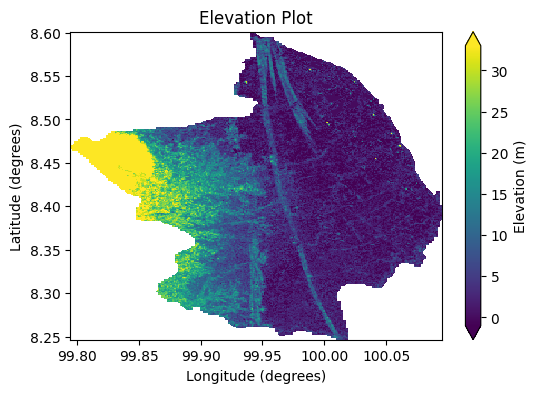

In [23]:
# Plotting the DEM
DEM = ee.Image("NASA/NASADEM_HGT/001").select("elevation").clip(AOI)
DEM_xarray = image_to_xarray(DEM, AOI, bands = "elevation", scale = 100, crs = "EPSG:4326")

  # Getting the min and max elevation thresholds for display
DEM_values = DEM_xarray.elevation.isel(time=0).values
  # Pick a percentile to ignore outliers
min_elevation = np.nanpercentile(DEM_values, 5)
max_elevation = np.nanpercentile(DEM_values, 95)


plt.figure(figsize=(6, 4))
DEM_xarray.elevation.isel(time=0).plot.imshow(x = 'lon', y = 'lat', vmin = min_elevation, vmax = max_elevation, cbar_kwargs = {"label": "Elevation (m)"})
plt.title("Elevation Plot")
plt.xlabel("Longitude (degrees)")
plt.ylabel("Latitude (degrees)")
plt.show()

*Figure 2: Elevation (metres) of each pixel*

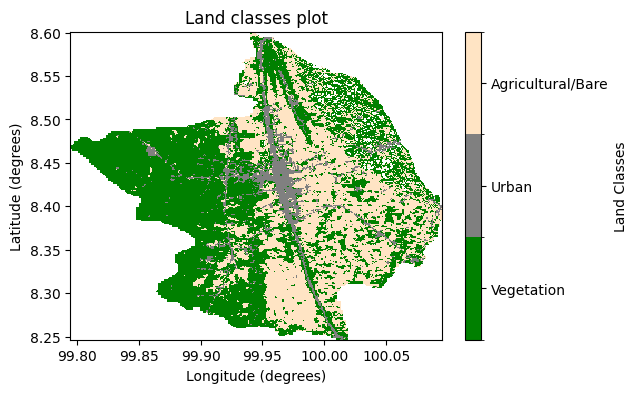

In [24]:
# Plotting the land classes
  # Converting the land cover class image into xarray dataset
land_cover_xarray = image_to_xarray(land_cover_reclassified, AOI, bands = "land_cover", scale = 100, crs = "EPSG:4326")

plt.figure(figsize=(6, 4))
tick_locations_land = [1, 2, 3]
land_classes_levels = [0.5, 1.5, 2.5, 3.5]  # This helps define each bin such that the label is at the centre of each colour in the colour bar
land_classes_palette = ["green", "grey", "bisque"]

land_cover_plot = land_cover_xarray.land_cover.isel(time=0).plot.imshow(
    x = 'lon',
    y = 'lat',
    levels = land_classes_levels,
    colors = land_classes_palette,
    cbar_kwargs = {"label": "Land Classes", "ticks": tick_locations_land})

land_cover_plot.colorbar.ax.set_yticklabels(descriptive_labels)
plt.title("Land classes plot")
plt.xlabel("Longitude (degrees)")
plt.ylabel("Latitude (degrees)")
plt.show()

*Figure 3: Land cover classes within Mueang Nakhon Si Thammarat District. The land cover are split into 3 classes (Vegetation, Urban, and Agricultural/Bare).*

**Interpretation:**

- Figure 1: Flooding was the most persistent in the east and south of the district, while the west side experienced little flooding.

- Figure 2: The district is very low-lying overall, with higher ground in the west and lower terrain toward the east. The long-duration flood clusters aligned with these low-elevation areas, consistent with ponding.

- Figure 3: The west is mostly vegetation, while the central and east is largely agricultural/bare, with urban areas along a narrow corridor. This means that persistent flooding areas mostly coincided with the low-lying agricultural/bare areas, while the higher-elevated vegetated areas to the west and central urban areas showed mostly short/no flooding.

#### 3.2) Mean flood duration for each land class

In [25]:
df

,land_class,mean,class_name
0,1,7.948531,Vegetation
1,2,3.473878,Urban
2,3,17.882647,Agricultural/Bare


*Table 1: Mean flooded duration (days) for vegetation, urban, and agricultural/bare land classes in Mueang Nakhon Si Thammarat District.*

Figure 4 saved to: /content/data/Fig_4_mean_flood_duration_bar_chart.png


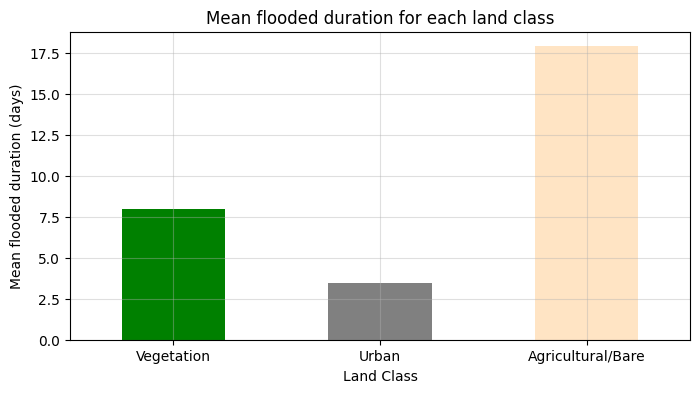

In [26]:
# Plotting the bar chart for mean flooded duration of each land class
fig_bar, ax_bar = plt.subplots(figsize = (8, 4))

df.plot(kind = "bar", x = "class_name", y = "mean", color = land_classes_palette, legend = False, ax = ax_bar)
ax_bar.set_ylabel("Mean flooded duration (days)")
ax_bar.set_xlabel("Land Class")
ax_bar.set_title("Mean flooded duration for each land class")
ax_bar.tick_params(axis="x", rotation = 0)
ax_bar.grid(alpha = 0.4)

  # Saving the bar chart (Figure 4)
fig_bar_path = directory / "Fig_4_mean_flood_duration_bar_chart.png"
fig_bar.savefig(fig_bar_path, dpi = 300)
print("Figure 4 saved to:", fig_bar_path.resolve())

plt.show()
plt.close(fig_bar)

*Figure 4:. Mean flooded duration (days) for each land class.*

**Interpretation:**

- The flood persisted the longest in agricultural/bare areas, followed by vegetated areas, and the shortest in urban areas.

- The agricultural/bare lands of Mueang Nakhon Si Thammarat have a low soil organic matter percentage (Limtong, 2012). Low soil organic matter reduces aggregate water stability, which promotes surface crusting and lowers water infiltration, leading to poor drainage (Bot and Benites, 2005). Additionally, southern Thailand contains many rubber and oil palm plantations (Acosta, 2025). Soil compaction can occur in rubber plantations via repeated trampling during harvesting, and in oil palm plantations via the frequent use of heavy machinery such as trucks (Guillaume et al., 2016), resulting in poorer drainage.

- Vegetated areas in Mueang Nakhon Si Thammarat contain mangrove and peat swamp forests in addition to evergreen forests (ESCAP, 2020). These forests can reduce the observed mean flooded duration by absorbing and storing the floodwater, such that water does not remain as open surface water detectable by SAR (Nature-Based Infrastructure, 2024). However, this also means that floodwater beneath mangrove or swamp forest canopies may be under-detected, and the mean flooded duration for vegetated areas is underestimated.

- Though urban areas contain more impermeable surfaces than vegetation or agricultural/bare land, they remained flooded for the shortest duration.
This could be because of the existing drainage systems and active flood clearance efforts.

Note that these interpretations are partly speculative, as the potential drivers have not been formally investigated in this project.

#### 3.3) Investigating Rainfall Data

In [27]:
# Defining and filtering the precipitation ImageCollection
precipitation = (ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
.filterDate('2016','2018')
.select('total_precipitation_sum')
.map(lambda x: x.clip(AOI).copyProperties(x, x.propertyNames())))

# Writing the ImageCollection into a pandas df containing the mean precipitation over the AOI at each month
pr_count = precipitation.size().getInfo()
pr_img_list = precipitation.toList(pr_count)

mean_pr_list = []
for i in range(pr_count):
    pr_img = ee.Image(pr_img_list.get(i))

    # Convert image to xarray
    pr_xarray = image_to_xarray(pr_img, AOI, bands = "total_precipitation_sum", scale = 250, crs = "EPSG:4326")

    # Spatial mean over AOI
    mean_pr = pr_xarray.total_precipitation_sum.mean(dim=("lat", "lon")).sortby('time') * 1000  # to convert m to mm
    mean_pr_list.append(mean_pr)

# Combining the mean list entries into a single xarray dataset
pr_all = xr.concat(mean_pr_list, dim = "time")

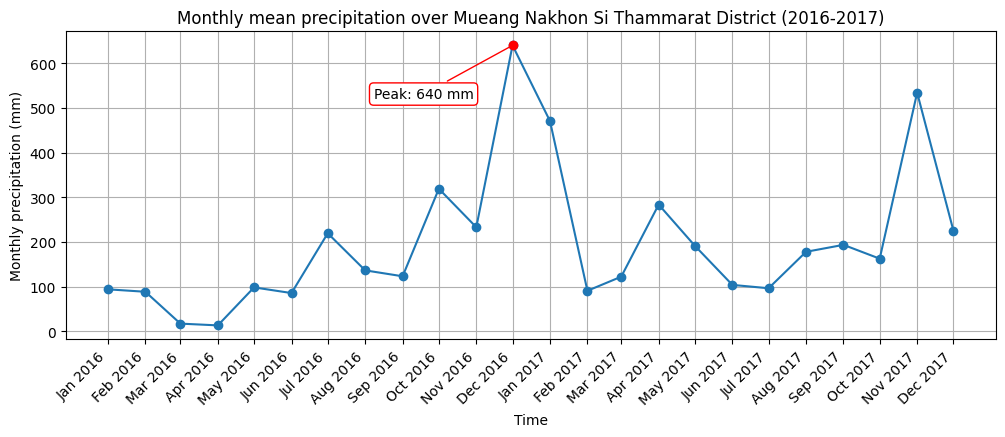

In [28]:
# Plotting the precipitation graph
fig_pr, ax_pr = plt.subplots(figsize = (12, 4))
pr_all.plot(marker = 'o', ax = ax_pr)

  # Get the formatted date strings for labels
date_labels = pr_all.time.dt.strftime('%b %Y').values
ax_pr.set_xticks(pr_all.time.values)
ax_pr.set_xticklabels(date_labels, rotation = 45, ha = 'right')

  # Highlighting the month with peak precipitation
peak_time = pr_all.idxmax().values
peak_value = pr_all.max().values

ax_pr.scatter(peak_time, peak_value, color = 'red', zorder = 5)
ax_pr.annotate(
    f'Peak: {peak_value:.0f} mm',
    xy = (peak_time, peak_value),
    xytext = (-100, -30),
    textcoords = 'offset points',
    arrowprops = dict(arrowstyle = '-', color = 'red'),
    bbox = dict(boxstyle = 'round, pad = 0.3', fc = 'white', ec = 'red'),
    ha = 'left',
    va = 'top')

plt.ylabel("Monthly precipitation (mm)")
plt.xlabel("Time")
plt.title("Monthly mean precipitation over Mueang Nakhon Si Thammarat District (2016-2017)")
plt.grid(True)
plt.show()

*Figure 5: Mean precipitation (mm) of each month over Mueang Nakhon Si Thammarat from 2016-2017*

**Interpretation:**
  - Precipitation peaks on Dec 2016 and remained high through Jan 2017: Aligns with the flood timeline, suggesting that heavy precipitation likely contributed to the flooding.

  - Heavy precipitation also coincides with southern Thailand's rainy season caused by northeast monsoon (THAI METEOROLOGICAL DEPARTMENT , 2025).

  

#### 3.4) Limitations

- The effective temporal sampling for this project was 12 days, meaning that any changes occurring within that time interval were not captured, leading to inaccuracy in estimates of flood timing and duration.

- The limited time frame means that the mean flooded duration could be underestimated for specific land classes, as they could’ve remained flooded for longer than this project’s scope (ex. some pixels reached the maximum measurable duration of 60 days).

- All working datasets were sampled at 250 m for ease of computation. However, this does not match the native resolution of the datasets. Resampling causes mixed pixels and blurred boundaries, reducing class-specific interpretability and the accuracy of flood duration of each class.

- Land classes were grouped into only 3 classes for simplicity. This resulted in loss of within-class variability, as each sub-class could have different properties (ex. porosity). As a result, explanations of land-cover controls on flood duration remained speculative.


## 4) Conclusions

Agricultural/bare areas remained flooded the longest (17.9 days), followed by vegetated areas (7.9 days) and urban areas (3.5 days).
Longer flood persistence was concentrated in low-elevation regions and coincided with heavy rainfall during the northeast monsoon period.
Overall, these findings indicate that both land cover and terrain influenced flood persistence, with monsoon-season rainfall likely contributing to the observed flooding.



##### **Future Improvements:**
- Using data with higher temporal resolution to more accurately capture short-lived changes in the flood.
- Incorporating additional data to help better explain the observed duration trend (ex. more detailed land cover and flood drainage networks/ defence infrastructures data).
- Use a more rigorous evaluation, such as spatial cross-validation, to obtain more realistic accuracy scores for the classifier. Points were drawn randomly within the same AOI, so spatial autocorrelation may inflate accuracy.



##### **What was learnt:**
- How to structure a remote sensing project workflow using Google Earth Engine Python API.
- How flood water interacts with land classes, particularly soil in agricultural land such as rubber and oil palm plantations, and vegetated land such as mangrove and peat swamp forests.
- Using robust validation checks to test the quality and consistency of the data before running further analysis.

## 5) References

- Acosta, Z. (2025). Thailand Agriculture: A Comprehensive Guide to One of Asia’s Most Vital Industries. [online] Eosglobalexpansion.com. Available at: https://eosglobalexpansion.com/thailand-agriculture-comprehensive-guide/.
- Bot, A. and Benites, J. (2005). Importance of soil organic matter. Rome: Fao
- ESCAP (2020). Nakhon Si Thammarat, Thailand. [online] Available at: https://www.unescap.org/sites/default/d8files/2020-08/NakhonSiThammarat.pdf.
- Guillaume, T., Holtkamp, A.M., Damris, M., Brümmer, B. and Kuzyakov, Y. (2016). Soil degradation in oil palm and rubber plantations under land resource scarcity. Agriculture, Ecosystems & Environment, 232, pp.110–118. doi: https://doi.org/10.1016/j.agee.2016.07.002.
- Limtong, P. (2012). Status and Priorities of Soil Management in Thailand Global Soil Partnership, Technical Workshop ‘on Managing Living Soils’. [online] Available at: https://www.fao.org/fileadmin/user_upload/GSP/docs/WS_managinglivingsoils/Limtong_Thailand.pdf.
- Nature-Based Infrastructure (2024). Wetlands - Nature-Based Infrastructure Global Resource Centre. [online] Nature-Based Infrastructure Global Resource Centre. Available at: https://nbi.iisd.org/wetlands/.
- THAI METEOROLOGICAL DEPARTMENT (2025). 3-month Climate Prediction of Thailand.